# Bland-Altman-Plot – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/bland-altman-plot)

Der **Bland-Altman-Plot** (auch: Differenzdiagramm) ist ein grafisches Werkzeug, um
**zwei Messverfahren miteinander zu vergleichen** und ihre Übereinstimmung zu beurteilen.

**Aufbau:**
- **x-Achse:** Mittelwert der beiden Messungen $\frac{M_1 + M_2}{2}$
- **y-Achse:** Differenz der beiden Messungen $M_1 - M_2$
- **Mittlere Differenz (Bias):** horizontale Linie auf Höhe $\bar{d}$
- **Limits of Agreement (LoA):** $\bar{d} \pm 1{,}96 \times s_d$

| Element | Formel | Bedeutung |
|---|---|---|
| **Differenz** | $d_i = M_{1i} - M_{2i}$ | Abweichung je Messung |
| **Mittlere Differenz (Bias)** | $\bar{d} = \frac{1}{n}\sum d_i$ | Systematischer Fehler |
| **Standardabweichung** | $s_d = \text{SD}(d_i)$ | Zufälliger Fehler |
| **Obere LoA** | $\bar{d} + 1{,}96 \times s_d$ | 95%-Übereinstimmungsgrenze oben |
| **Untere LoA** | $\bar{d} - 1{,}96 \times s_d$ | 95%-Übereinstimmungsgrenze unten |

**Typische Anwendungen:**
- Medizin: neue Messmethode vs. Goldstandard (z. B. Blutzucker, Blutdruck)
- Industrie: zwei Messgeräte vergleichen
- Qualitätskontrolle: Messsystemvergleich

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Warum nicht einfach ein Streudiagramm?

Ein häufiger Fehler ist es, zwei Messverfahren mit einem gewöhnlichen Streudiagramm
(Methode 1 vs. Methode 2) zu vergleichen und dann die Korrelation zu berechnen.

**Problem:** Eine hohe Korrelation bedeutet **nicht** zwingend gute Übereinstimmung!
Zwei Methoden können hoch korrelieren und trotzdem systematisch voneinander abweichen.

> **Bland & Altman (1986)** schlugen daher vor, stattdessen die **Differenz gegen
> den Mittelwert** aufzutragen – das macht systematische und zufällige Fehler direkt
> sichtbar.

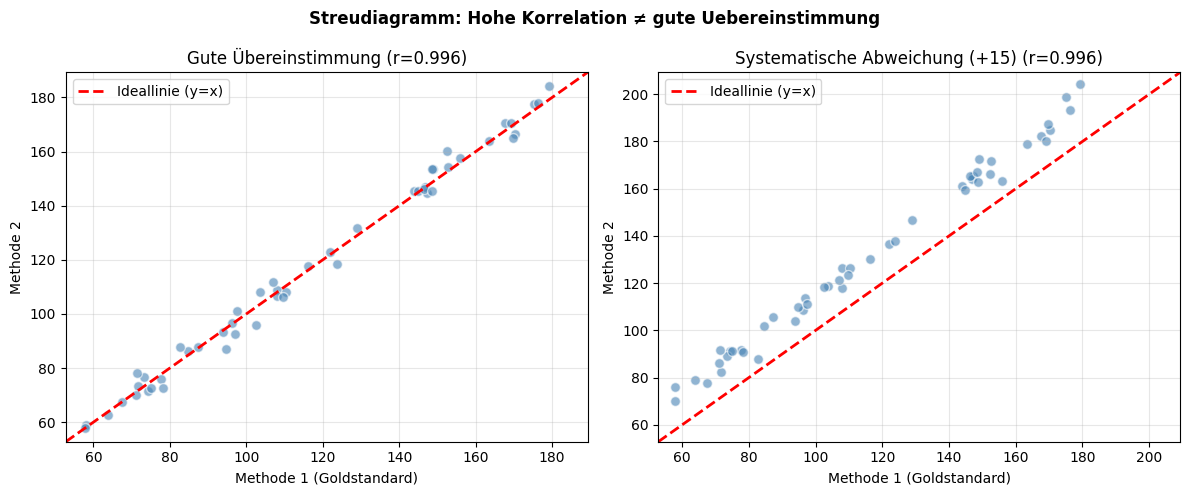

Beide Streudiagramme zeigen r > 0.99 – aber nur links ist die Uebereinstimmung gut!


In [2]:
# Warum Streudiagramm nicht ausreicht – Demonstration
np.random.seed(1)
wahre_werte = np.random.uniform(60, 180, 50)

# Methode 1: Goldstandard (mit kleinem Fehler)
methode_1 = wahre_werte + np.random.normal(0, 3, 50)

# Methode 2a: gut uebereinstimmend
methode_2a = methode_1 + np.random.normal(0, 4, 50)

# Methode 2b: systematisch um 15 mmHg zu hoch, trotzdem hohe Korrelation
methode_2b = methode_1 + 15 + np.random.normal(0, 4, 50)

korr_a = np.corrcoef(methode_1, methode_2a)[0, 1]
korr_b = np.corrcoef(methode_1, methode_2b)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Streudiagramm: Hohe Korrelation ≠ gute Uebereinstimmung",
             fontsize=12, fontweight="bold")

for ax, m2, titel, korr in zip(
    axes,
    [methode_2a, methode_2b],
    ["Gute Übereinstimmung", "Systematische Abweichung (+15)"],
    [korr_a, korr_b]
):
    ax.scatter(methode_1, m2, color="steelblue", alpha=0.6,
               edgecolors="white", s=50)
    lims = [min(methode_1.min(), m2.min())-5,
            max(methode_1.max(), m2.max())+5]
    ax.plot(lims, lims, "r--", linewidth=2, label="Ideallinie (y=x)")
    ax.set_xlabel("Methode 1 (Goldstandard)")
    ax.set_ylabel("Methode 2")
    ax.set_title(titel + " (r=" + str(round(korr, 3)) + ")")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()
print("Beide Streudiagramme zeigen r > 0.99 – aber nur links ist die Uebereinstimmung gut!")

## 2. Berechnung Schritt für Schritt

**Gegeben:** $n$ Personen, jeweils gemessen mit Methode 1 und Methode 2.

**Schritt 1:** Differenz berechnen: $d_i = M_{1i} - M_{2i}$

**Schritt 2:** Mittelwert berechnen: $\bar{m}_i = \frac{M_{1i} + M_{2i}}{2}$

**Schritt 3:** Mittlere Differenz (Bias): $\bar{d} = \frac{1}{n}\sum_{i=1}^n d_i$

**Schritt 4:** Standardabweichung der Differenzen: $s_d = \text{SD}(d_i)$

**Schritt 5:** Limits of Agreement (LoA):
$$\text{LoA}_{\text{oben}} = \bar{d} + 1{,}96 \times s_d$$
$$\text{LoA}_{\text{unten}} = \bar{d} - 1{,}96 \times s_d$$

> Innerhalb der LoA liegen ca. **95 %** der Differenzen, wenn diese
> normalverteilt sind.

In [3]:
# Beispiel: Blutzuckermessung – zwei Messgeraete (numiqo-Beispiel)
np.random.seed(42)
n = 40
blutzucker_referenz = np.random.uniform(70, 200, n)

# Neues Geraet: leicht positiver Bias + zufaelliger Fehler
blutzucker_neu = blutzucker_referenz + np.random.normal(3.5, 6, n)

# Berechnungen
mittelwert_i = (blutzucker_referenz + blutzucker_neu) / 2
differenz_i  = blutzucker_referenz - blutzucker_neu

bias    = differenz_i.mean()
sd_diff = differenz_i.std(ddof=1)
loa_o   = bias + 1.96 * sd_diff
loa_u   = bias - 1.96 * sd_diff

print("Bland-Altman Kennzahlen: Blutzucker")
print(f"n:                    {n}")
print(f"Mittlere Differenz    (Bias):  {bias:.3f} mmol/L")
print(f"Standardabweichung    (SD_d):  {sd_diff:.3f} mmol/L")
print(f"Obere LoA  (Bias + 1.96*SD):  {loa_o:.3f} mmol/L")
print(f"Untere LoA (Bias - 1.96*SD):  {loa_u:.3f} mmol/L")
print()

# Anteil innerhalb der LoA
innerhalb = ((differenz_i >= loa_u) & (differenz_i <= loa_o)).mean() * 100
print(f"Anteil Punkte innerhalb LoA:  {innerhalb:.1f} %  (erwartet: ~95 %)")

# Tabelle der ersten 8 Messpaare
df_ba = pd.DataFrame({
    "Referenz":    blutzucker_referenz[:8].round(1),
    "Neu":         blutzucker_neu[:8].round(1),
    "Mittelwert":  mittelwert_i[:8].round(2),
    "Differenz":   differenz_i[:8].round(2),
})
print()
print("Erste 8 Messpaare:")
print(df_ba.to_string(index=False))

Bland-Altman Kennzahlen: Blutzucker
n:                    40
Mittlere Differenz    (Bias):  -3.030 mmol/L
Standardabweichung    (SD_d):  5.351 mmol/L
Obere LoA  (Bias + 1.96*SD):  7.458 mmol/L
Untere LoA (Bias - 1.96*SD):  -13.517 mmol/L

Anteil Punkte innerhalb LoA:  97.5 %  (erwartet: ~95 %)

Erste 8 Messpaare:
 Referenz   Neu  Mittelwert  Differenz
    118.7 122.1      120.40      -3.42
    193.6 190.7      192.17       2.85
    165.2 173.6      169.38      -8.44
    147.8 144.0      145.91       3.83
     90.3  95.0       92.66      -4.75
     90.3  82.0       86.15       8.26
     77.6  73.1       75.32       4.47
    182.6 187.3      184.94      -4.68


## 3. Der Bland-Altman-Plot – vollständig annotiert

**Interpretation der Linien:**
- **Durchgezogene Linie** (Bias): systematische Abweichung zwischen den Methoden
- **Gestrichelte Linien** (LoA): Bereich, in dem 95 % der Differenzen liegen
- **Nulllinie** (grau gepunktet): perfekte Übereinstimmung (kein Bias)

**Ideal:** Bias nahe 0, LoA-Bereich klinisch/praktisch akzeptabel,
Punkte zufällig verteilt ohne Muster.

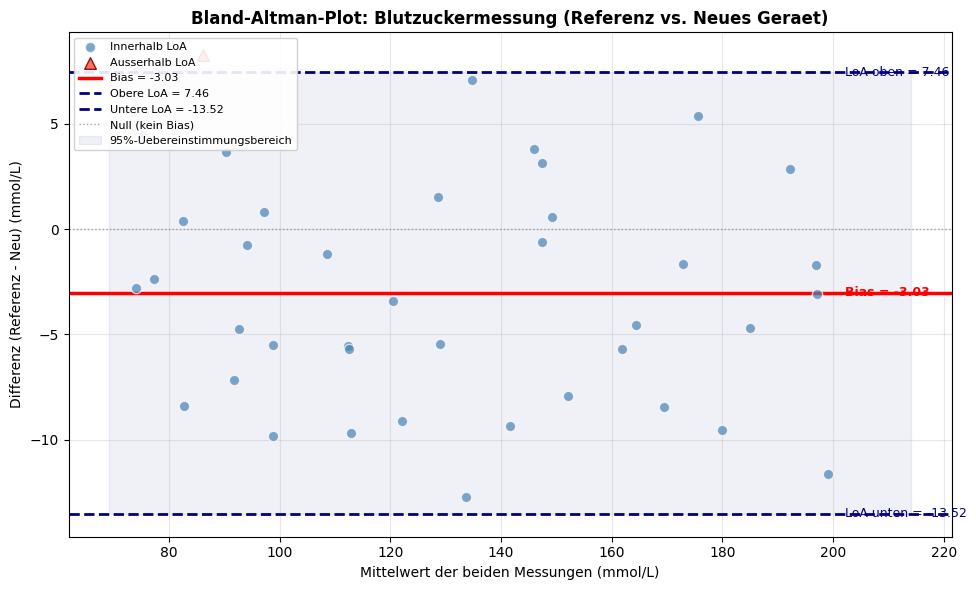

In [4]:
# Vollstaendig annotierter Bland-Altman-Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Punkte
ausreisser_mask = (differenz_i < loa_u) | (differenz_i > loa_o)
ax.scatter(mittelwert_i[~ausreisser_mask], differenz_i[~ausreisser_mask],
           color="steelblue", alpha=0.7, edgecolors="white", s=55,
           label="Innerhalb LoA", zorder=3)
ax.scatter(mittelwert_i[ausreisser_mask], differenz_i[ausreisser_mask],
           color="tomato", alpha=0.9, edgecolors="darkred", s=70,
           label="Ausserhalb LoA", zorder=4, marker="^")

# Referenzlinien
ax.axhline(bias,  color="red",    linewidth=2.5, linestyle="-",
           label="Bias = " + str(round(bias, 2)))
ax.axhline(loa_o, color="navy",   linewidth=2,   linestyle="--",
           label="Obere LoA = " + str(round(loa_o, 2)))
ax.axhline(loa_u, color="navy",   linewidth=2,   linestyle="--",
           label="Untere LoA = " + str(round(loa_u, 2)))
ax.axhline(0,     color="gray",   linewidth=1,   linestyle=":",
           label="Null (kein Bias)", alpha=0.7)

# Annotierungen rechts
x_ann = mittelwert_i.max() + 3
ax.annotate("Bias = " + str(round(bias, 2)),
            xy=(x_ann, bias), fontsize=9, color="red",
            va="center", fontweight="bold")
ax.annotate("LoA oben = " + str(round(loa_o, 2)),
            xy=(x_ann, loa_o), fontsize=9, color="navy", va="center")
ax.annotate("LoA unten = " + str(round(loa_u, 2)),
            xy=(x_ann, loa_u), fontsize=9, color="navy", va="center")

# Schattierter LoA-Bereich
ax.fill_between([mittelwert_i.min()-5, mittelwert_i.max()+15],
                loa_u, loa_o, alpha=0.06, color="navy",
                label="95%-Uebereinstimmungsbereich")

ax.set_title("Bland-Altman-Plot: Blutzuckermessung (Referenz vs. Neues Geraet)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Mittelwert der beiden Messungen (mmol/L)")
ax.set_ylabel("Differenz (Referenz - Neu) (mmol/L)")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Typische Muster und ihre Interpretation

| Muster im Plot | Bedeutung |
|---|---|
| Punkte zufällig um Bias-Linie verteilt | Nur zufälliger Fehler – gut |
| Bias ≠ 0, aber konstant | Systematischer Fehler (fixe Abweichung) |
| Streuung nimmt mit dem Mittelwert zu | Proportionaler Fehler – Transformation nötig |
| Trend (ansteigende/fallende Differenzen) | Methoden stimmen bei großen/kleinen Werten schlechter überein |
| Viele Punkte außerhalb LoA | Schlechte Übereinstimmung |

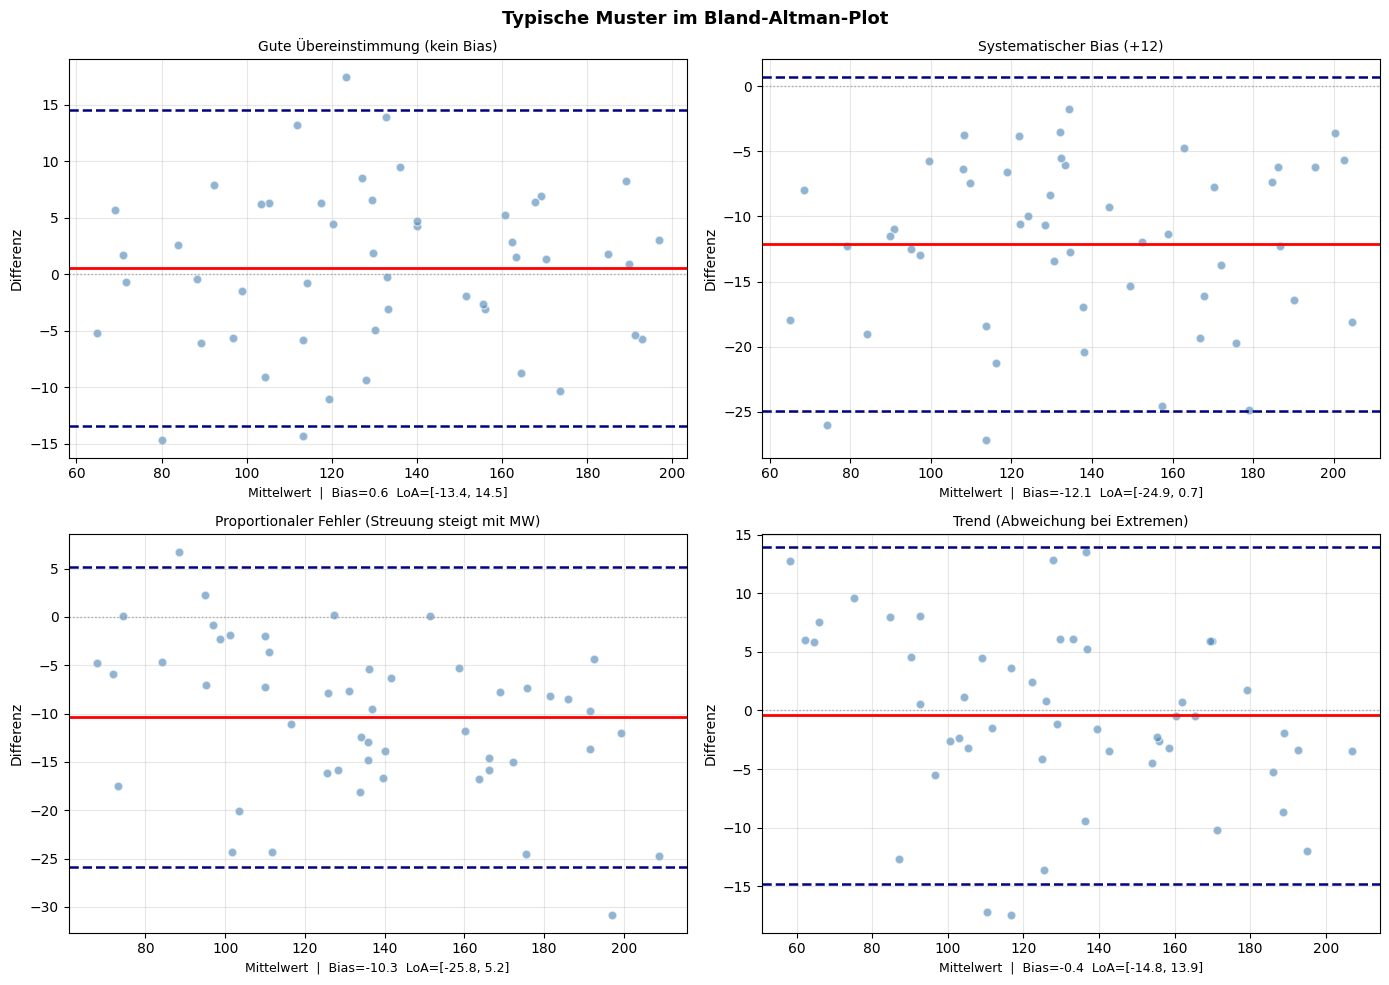

In [8]:
# Vier typische Muster im Bland-Altman-Plot
np.random.seed(7)
n_m = 50
x_base = np.random.uniform(60, 200, n_m)

szenarien = [
    (x_base + np.random.normal(0, 5, n_m),
     x_base + np.random.normal(0, 5, n_m),
     "Gute Übereinstimmung (kein Bias)"),
    (x_base + np.random.normal(0, 5, n_m),
     x_base + np.random.normal(12, 5, n_m),
     "Systematischer Bias (+12)"),
    (x_base + np.random.normal(0, 5, n_m),
     x_base * 1.08 + np.random.normal(0, 5, n_m),
     "Proportionaler Fehler (Streuung steigt mit MW)"),
    (x_base + np.random.normal(0, 5, n_m),
     x_base + 0.06*(x_base-130) + np.random.normal(0, 5, n_m),
     "Trend (Abweichung bei Extremen)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Typische Muster im Bland-Altman-Plot", fontsize=13, fontweight="bold")

for ax, (m1, m2, titel) in zip(axes.flat, szenarien):
    mw_s = (m1 + m2) / 2
    d_s  = m1 - m2
    bias_s = d_s.mean()
    sd_s   = d_s.std(ddof=1)
    loa_os = bias_s + 1.96 * sd_s
    loa_us = bias_s - 1.96 * sd_s

    ax.scatter(mw_s, d_s, color="steelblue", alpha=0.6, edgecolors="white", s=40)
    ax.axhline(bias_s, color="red",  linewidth=2,   linestyle="-")
    ax.axhline(loa_os, color="navy", linewidth=1.8, linestyle="--")
    ax.axhline(loa_us, color="navy", linewidth=1.8, linestyle="--")
    ax.axhline(0,      color="gray", linewidth=1,   linestyle=":", alpha=0.6)

    ax.set_title(titel, fontsize=10)
    ax.set_ylabel("Differenz")
    ax.grid(alpha=0.3)

    info = ("Bias=" + str(round(bias_s, 1)) +
            "  LoA=[" + str(round(loa_us, 1)) +
            ", " + str(round(loa_os, 1)) + "]")
    ax.set_xlabel("Mittelwert  |  " + info, fontsize=9)

plt.tight_layout()
plt.show()


## 5. Konfidenzintervalle der Limits of Agreement

Die Limits of Agreement sind selbst **Schätzungen** und haben daher
Konfidenzintervalle (KI). Bei kleinen Stichproben (n < 50) sollten diese
immer angegeben werden.

**95%-KI für den Bias:**
$$\bar{d} \pm t_{0.975,\, n-1} \times \frac{s_d}{\sqrt{n}}$$

**95%-KI für die LoA** (näherungsweise):
$$\text{LoA} \pm t_{0.975,\, n-1} \times s_d \times \sqrt{\frac{3}{n}}$$

=== Bland-Altman mit 95%-Konfidenzintervallen ===
n = 40
Bias:      -3.03  95%-KI [-4.74, -1.32]
LoA oben:  7.46  95%-KI [4.49, 10.42]
LoA unten: -13.52  95%-KI [-16.48, -10.55]


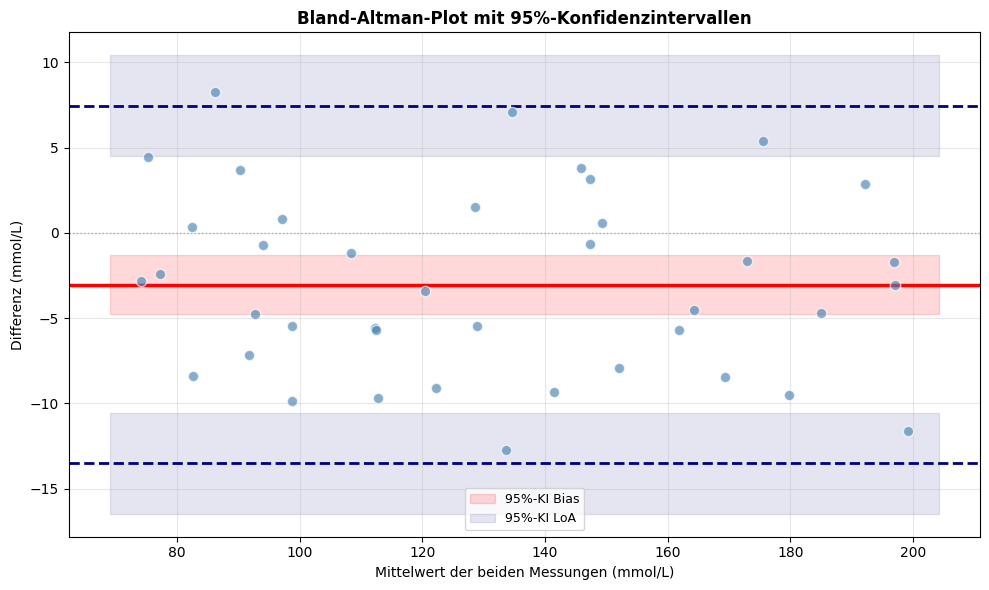

In [6]:
# Bland-Altman mit Konfidenzintervallen
from scipy.stats import t as t_dist

n_ki = len(differenz_i)
t_krit = t_dist.ppf(0.975, df=n_ki - 1)

# KI fuer Bias
sem_bias = sd_diff / np.sqrt(n_ki)
ki_bias_u = bias - t_krit * sem_bias
ki_bias_o = bias + t_krit * sem_bias

# KI fuer LoA (Naeherung nach Bland & Altman)
se_loa = sd_diff * np.sqrt(3.0 / n_ki)
ki_loa_o_u = loa_o - t_krit * se_loa
ki_loa_o_o = loa_o + t_krit * se_loa
ki_loa_u_u = loa_u - t_krit * se_loa
ki_loa_u_o = loa_u + t_krit * se_loa

print("=== Bland-Altman mit 95%-Konfidenzintervallen ===")
print(f"n = {n_ki}")
print(f"Bias:      {bias:.2f}  95%-KI [{ki_bias_u:.2f}, {ki_bias_o:.2f}]")
print(f"LoA oben:  {loa_o:.2f}  95%-KI [{ki_loa_o_u:.2f}, {ki_loa_o_o:.2f}]")
print(f"LoA unten: {loa_u:.2f}  95%-KI [{ki_loa_u_u:.2f}, {ki_loa_u_o:.2f}]")

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(mittelwert_i, differenz_i, color="steelblue",
           alpha=0.65, edgecolors="white", s=55, zorder=3)

# Bias + KI
ax.axhline(bias,  color="red",   linewidth=2.5, linestyle="-")
ax.fill_between([mittelwert_i.min()-5, mittelwert_i.max()+5],
                ki_bias_u, ki_bias_o, alpha=0.15, color="red",
                label="95%-KI Bias")
# LoA oben + KI
ax.axhline(loa_o, color="navy",  linewidth=2, linestyle="--")
ax.fill_between([mittelwert_i.min()-5, mittelwert_i.max()+5],
                ki_loa_o_u, ki_loa_o_o, alpha=0.1, color="navy",
                label="95%-KI LoA")
# LoA unten + KI
ax.axhline(loa_u, color="navy",  linewidth=2, linestyle="--")
ax.fill_between([mittelwert_i.min()-5, mittelwert_i.max()+5],
                ki_loa_u_u, ki_loa_u_o, alpha=0.1, color="navy")
ax.axhline(0,    color="gray",  linewidth=1, linestyle=":", alpha=0.6)

ax.set_title("Bland-Altman-Plot mit 95%-Konfidenzintervallen", fontsize=12, fontweight="bold")
ax.set_xlabel("Mittelwert der beiden Messungen (mmol/L)")
ax.set_ylabel("Differenz (mmol/L)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Wiederverwendbare Funktion

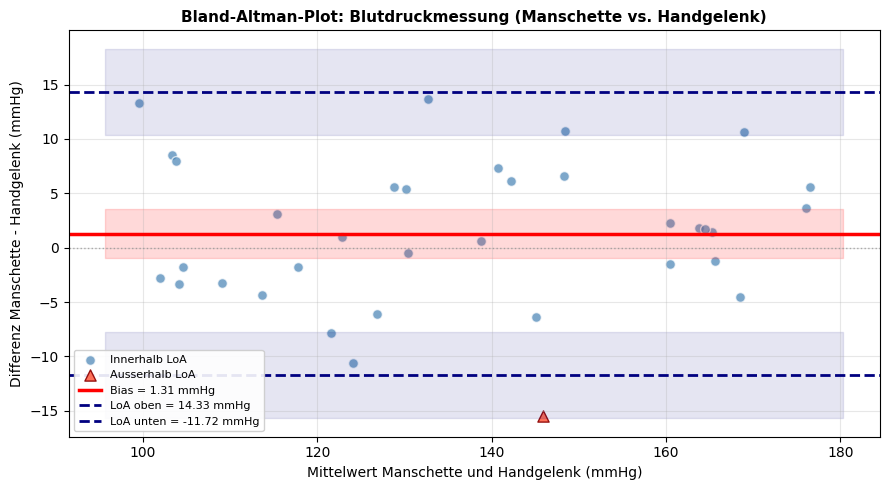

Bias: 1.31 mmHg  |  LoA: [-11.72, 14.33] mmHg


In [7]:
def bland_altman_plot(methode_1, methode_2,
                      einheit="",
                      name_1="Methode 1",
                      name_2="Methode 2",
                      mit_ki=True,
                      ax=None):
    # Erstellt einen vollstaendigen Bland-Altman-Plot.
    # Parameter:
    #   methode_1, methode_2 : array-like  – die beiden Messreihen
    #   einheit              : str         – Einheit fuer Achsenbeschriftung
    #   name_1, name_2       : str         – Namen der Methoden
    #   mit_ki               : bool        – 95%-KI einzeichnen
    #   ax                   : matplotlib Axes oder None
    m1 = np.asarray(methode_1)
    m2 = np.asarray(methode_2)
    mw  = (m1 + m2) / 2
    d   = m1 - m2
    n   = len(d)

    bias   = d.mean()
    sd_d   = d.std(ddof=1)
    loa_o_ = bias + 1.96 * sd_d
    loa_u_ = bias - 1.96 * sd_d

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    ausrss = (d < loa_u_) | (d > loa_o_)
    ax.scatter(mw[~ausrss], d[~ausrss], color="steelblue",
               alpha=0.7, edgecolors="white", s=50, label="Innerhalb LoA")
    if ausrss.any():
        ax.scatter(mw[ausrss], d[ausrss], color="tomato",
                   alpha=0.9, edgecolors="darkred", s=65,
                   marker="^", label="Ausserhalb LoA")

    x_min = mw.min() - (mw.max()-mw.min())*0.05
    x_max = mw.max() + (mw.max()-mw.min())*0.05

    if mit_ki:
        t_k = t_dist.ppf(0.975, df=n-1)
        se_b = sd_d / np.sqrt(n)
        se_l = sd_d * np.sqrt(3.0 / n)
        ax.fill_between([x_min, x_max],
                        bias - t_k*se_b, bias + t_k*se_b,
                        alpha=0.15, color="red")
        for loa_val in [loa_o_, loa_u_]:
            ax.fill_between([x_min, x_max],
                            loa_val - t_k*se_l, loa_val + t_k*se_l,
                            alpha=0.1, color="navy")

    ax.axhline(bias,   color="red",  linewidth=2.5, linestyle="-",
               label="Bias = " + str(round(bias, 2)) + " " + einheit)
    ax.axhline(loa_o_, color="navy", linewidth=2,   linestyle="--",
               label="LoA oben = " + str(round(loa_o_, 2)) + " " + einheit)
    ax.axhline(loa_u_, color="navy", linewidth=2,   linestyle="--",
               label="LoA unten = " + str(round(loa_u_, 2)) + " " + einheit)
    ax.axhline(0,      color="gray", linewidth=1,   linestyle=":", alpha=0.6)

    einheit_str = " (" + einheit + ")" if einheit else ""
    ax.set_xlabel("Mittelwert " + name_1 + " und " + name_2 + einheit_str)
    ax.set_ylabel("Differenz " + name_1 + " - " + name_2 + einheit_str)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.3)
    return bias, sd_d, loa_o_, loa_u_


# ── Test: Blutdruck-Beispiel ──────────────────────────────────────────────────
np.random.seed(99)
n_bp = 35
systolisch_referenz = np.random.uniform(100, 180, n_bp)
systolisch_neu      = systolisch_referenz + np.random.normal(-2, 7, n_bp)

fig, ax = plt.subplots(figsize=(9, 5))
bias_r, sd_r, loa_o_r, loa_u_r = bland_altman_plot(
    systolisch_referenz, systolisch_neu,
    einheit="mmHg",
    name_1="Manschette",
    name_2="Handgelenk",
    mit_ki=True,
    ax=ax
)
ax.set_title("Bland-Altman-Plot: Blutdruckmessung (Manschette vs. Handgelenk)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Bias: " + str(round(bias_r, 2)) + " mmHg  |  LoA: [" +
      str(round(loa_u_r, 2)) + ", " + str(round(loa_o_r, 2)) + "] mmHg")


## 7. Zusammenfassung

```
Bland-Altman-Plot – Übersicht
│
├── ACHSEN
│   ├── x-Achse: Mittelwert beider Messungen  = (M1 + M2) / 2
│   └── y-Achse: Differenz beider Messungen   = M1 - M2
│
├── LINIEN
│   ├── Bias (durchgezogen, rot):   d_quer = Mittelwert aller Differenzen
│   ├── LoA oben (gestrichelt):     Bias + 1.96 * SD_d
│   ├── LoA unten (gestrichelt):    Bias - 1.96 * SD_d
│   └── Nulllinie (gepunktet):      perfekte Uebereinstimmung (kein Bias)
│
├── INTERPRETATION
│   ├── Bias nahe 0            → kein systematischer Fehler
│   ├── Enger LoA-Bereich      → gute Uebereinstimmung
│   ├── ~95% Punkte innerhalb  → Normalverteilung der Differenzen OK
│   ├── Trend / Muster         → proportionaler Fehler, Transformation noetig
│   └── Punkte ausserhalb LoA  → Ausreisser, schlechte Uebereinstimmung
│
├── KONFIDENZINTERVALLE (wichtig bei n < 50)
│   ├── KI Bias:  Bias +/- t * SD / sqrt(n)
│   └── KI LoA:   LoA  +/- t * SD * sqrt(3/n)
│
└── EINSATZGEBIETE
    ├── Medizin:    neue Messmethode vs. Goldstandard
    ├── Industrie:  zwei Messgeraete vergleichen
    └── Forschung:  Reliabilitaet / Messuebereinstimmung
```

---
Quelle: [numiqo.de/tutorial/bland-altman-plot](https://numiqo.de/tutorial/bland-altman-plot)